In [1]:
import pandas as pd
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import json

def load_results(results): 
    
    with open(src_path, 'rb') as file:
        results_inference = pickle.load(file)
        
    ResultasDataset = {}
    tools = ['Avatars K5', "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
    for tool, result_as_attributes in results_inference.items():
        tool_res = {}
        for feature in result_as_attributes:
            name_feature = feature[0]
            evaluator = feature[1]
    
            attack_risk = evaluator.risk().value
            naive_risk = evaluator.risk(baseline=True).value
    
            if attack_risk <= naive_risk:
                final_risk = np.nan
            else:
                final_risk = attack_risk
            tool_res[name_feature] = final_risk
    
        ResultasDataset[tool] = tool_res
        
    df = pd.DataFrame(ResultasDataset).T
    df.index = tools

    return df

def extract_num_clincal(datapath, metadata, number_clinical):
    original_data = pd.read_csv(datapath, index_col = 0)
    clinical_features = original_data.columns.tolist()[0:number_clinical]
    numerical_type = ['numerical']
    numerical_features = [i.replace(".", "_") for i, value_type in metadata.items() if value_type in numerical_type and i in clinical_features]

    return numerical_features

def rearrange(data, numerical_clinical_features):
    df_numerical = data.loc[:,numerical_clinical_features]
    df_categorical = data.loc[:, ~df_results.columns.isin(numerical_clinical_features)]
    
    df_merged = pd.concat([df_numerical,df_categorical], axis = 1)

    return df_merged

In [2]:
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
num_clinical = [52,47,14]
seed = 42
Inference_Results = {}
NumericalClinical = {}
for i, cancer in enumerate(cancers):
    if cancer == 'ccRCC':
        metadata_path = f'../{cancer}/Data/feature_metadata.json'
    else:
        metadata_path = f'../{cancer}/Data/metadata.json'
    src_path = f'../{cancer}/Privacy/Inference/Seed_{seed}/results_inferences.pkl'
    data_path = f'../{cancer}/Data/original_data.csv'
    df_results = load_results(src_path)
    
    with open(metadata_path, 'r') as file:
        metadata = json.load(file)
    
    numerical_clinical = extract_num_clincal(data_path, metadata, number_clinical = num_clinical[i])
    
    df_final = rearrange(df_results, numerical_clinical)
    Inference_Results[cancer]=df_final
    NumericalClinical[cancer]=numerical_clinical

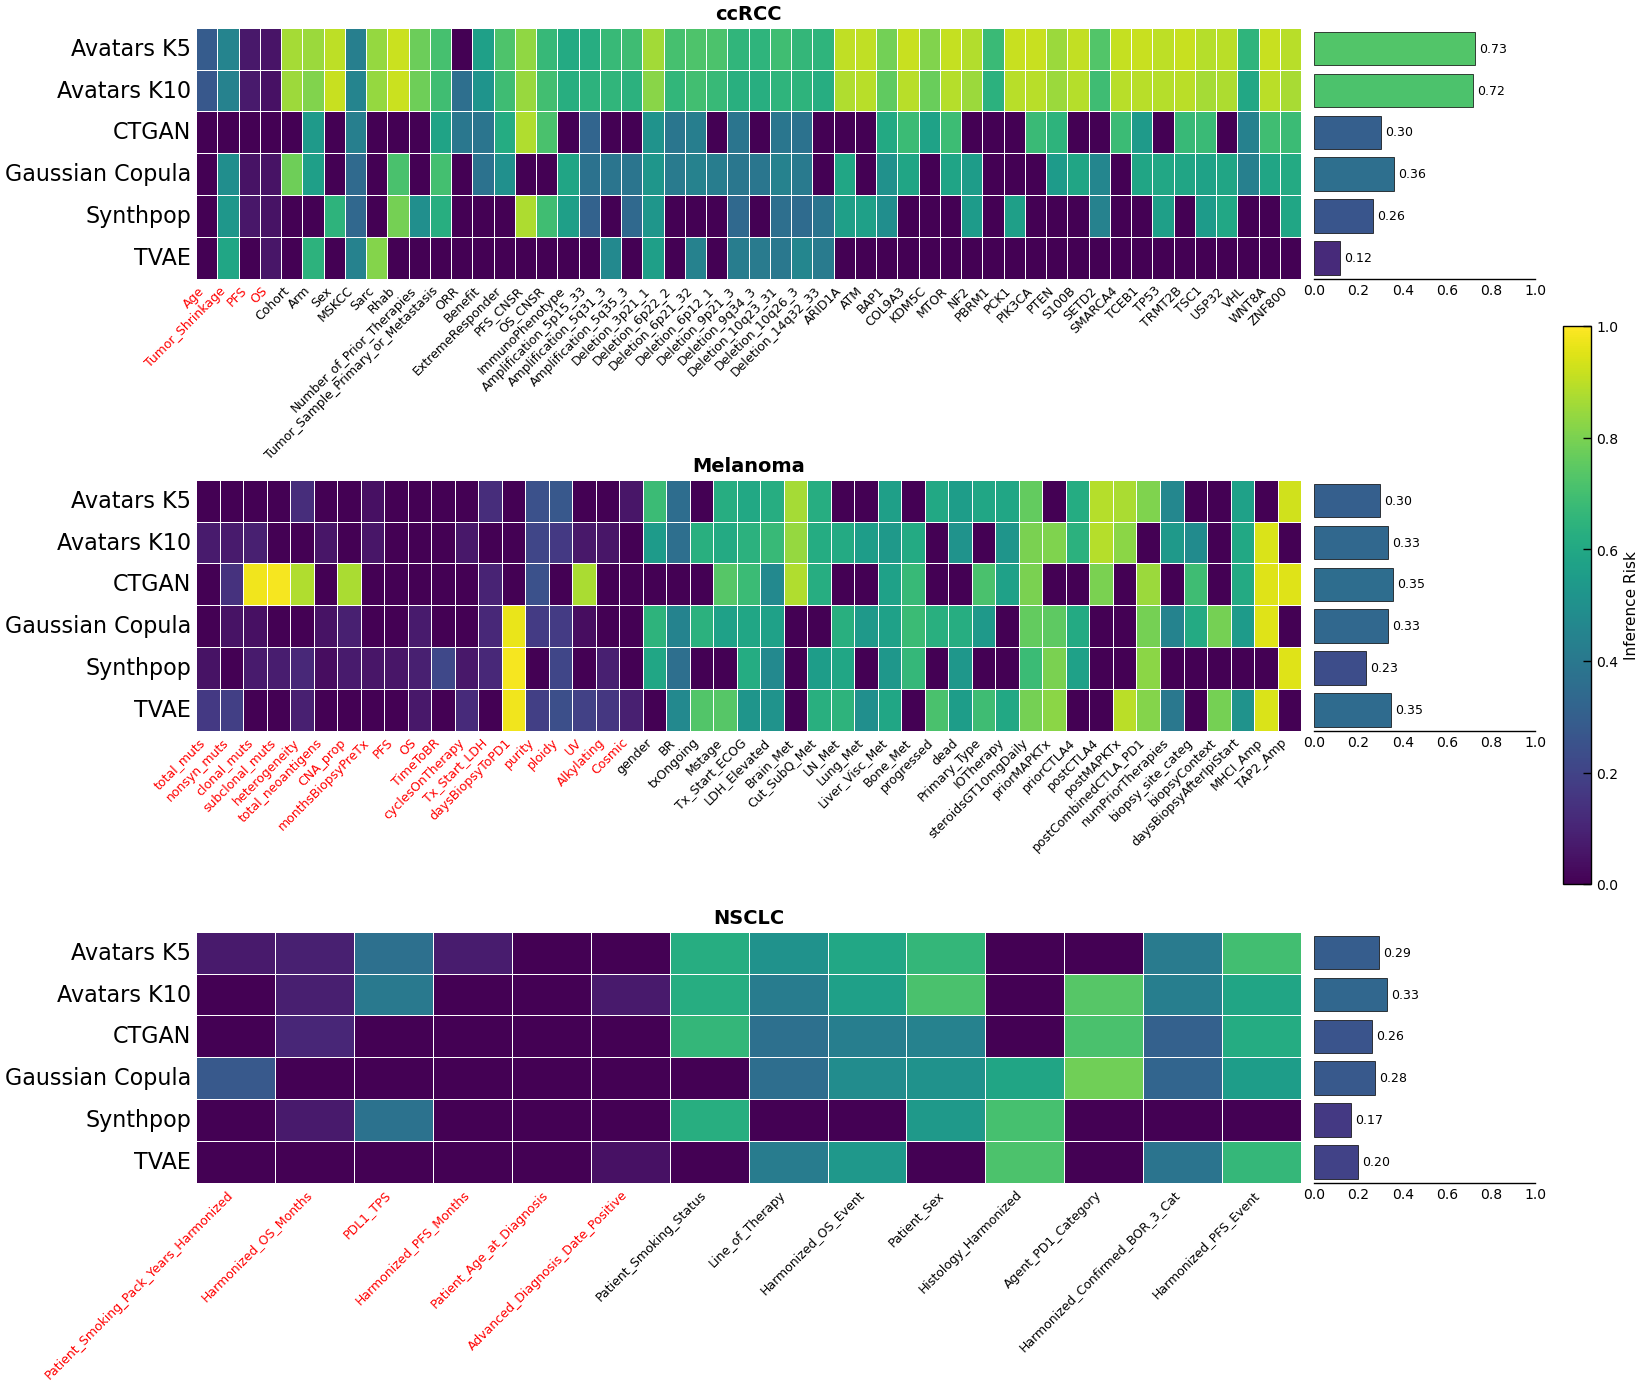

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import colors


plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False
})


vmin, vmax = 0, 1
cmap = plt.get_cmap("viridis")
norm = colors.Normalize(vmin=vmin, vmax=vmax)

# ===============================
# 3. FIGURE LAYOUT
# ===============================
fig, axes = plt.subplots(
    3, 2,
    figsize=(18, 15),
    gridspec_kw={
        'width_ratios': [1, 0.20],
        'wspace': 0.02,
        'hspace': 0.8
    }
)

datasets = ['ccRCC', 'Melanoma', 'NSCLC']
line_params = {'linewidths': 0.4, 'linecolor': 'white'}

for i, name in enumerate(datasets):

    ax_heat = axes[i, 0]
    ax_bar  = axes[i, 1]

    data = Inference_Results[name]

    # -------- HEATMAP --------
    sns.heatmap(
        data,
        ax=ax_heat,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=True,
        **line_params
    )

    ax_heat.set_title(name, loc='center', fontsize=14, fontweight='bold')
    ax_heat.tick_params(which='major', top=False, bottom=False, left=False, right=False)
    # X-label styling
    for label in ax_heat.get_xticklabels():
        if label.get_text() in NumericalClinical[name]:
            label.set_color('red')
        label.set_rotation(45)
        label.set_fontsize(9)
        label.set_ha('right')

    # -------- BAR PLOT (ROW-WISE SUMMARY) --------
    means = data.mean(axis=1)

    # 🔑 LẤY VỊ TRÍ Y CHUẨN TỪ HEATMAP
    y_pos = ax_heat.get_yticks()

    # 🔑 MAP MÀU THEO CÙNG VIRIDIS + NORMALIZE
    bar_colors = cmap(norm(means.values))

    bars = ax_bar.barh(
        y_pos,
        means.values,
        color=bar_colors,
        height=0.8,
        edgecolor='black',
        linewidth=0.5
    )

    # Đồng bộ trục Y
    ax_bar.set_ylim(ax_heat.get_ylim())
    # ax_bar.invert_yaxis()
    ax_bar.set_xlim(vmin, vmax)

    # Hiển thị giá trị mean
    ax_bar.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    # Clean bar axis
    # ax_bar.set_yticks([])
    # ax_bar.set_ylabel("")
    # ax_bar.spines['left'].set_visible(False)
    # ax_bar.tick_params(left=False)
    # ax_bar.tick_params(which='major', top=False, bottom=False, left=False, right=False)
    # ax_bar.tick_params(axis='x', labelsize=10)
    ax_bar.set_yticks([])
    ax_bar.set_ylabel("")
    ax_bar.spines['left'].set_visible(False)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.tick_params(axis='x', labelsize=10)
    ax_bar.tick_params(which='both', left=False)
    ax_bar.tick_params(which='major', top=False, bottom=False, left=False, right=False)
# ===============================
# 5. SHARED COLORBAR
# ===============================
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation='vertical',
    fraction=0.02,
    pad=0.02
)
cbar.set_label("Inference Risk", fontsize=11)
cbar.ax.tick_params(labelsize=10)
fig.savefig(
    'InferenceRisk.pdf',   
    dpi=300,          
    bbox_inches='tight'
)
plt.show()

In [1]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import json
from matplotlib import colors
import matplotlib.patches as mpatches

# =========================
# LOAD SINGLE SEED
# =========================
def load_results(src_path):

    with open(src_path, 'rb') as file:
        results_inference = pickle.load(file)

    tools = ['Avatars K5', "Avatars K10", "CTGAN",
             "Gaussian Copula", "Synthpop", "TVAE"]

    ResultasDataset = {}

    for tool, result_as_attributes in results_inference.items():
        tool_res = {}
        for feature in result_as_attributes:
            name_feature = feature[0]
            evaluator = feature[1]

            attack_risk = evaluator.risk().value
            naive_risk = evaluator.risk(baseline=True).value

            if attack_risk <= naive_risk:
                final_risk = np.nan
            else:
                final_risk = attack_risk

            tool_res[name_feature] = final_risk

        ResultasDataset[tool] = tool_res

    df = pd.DataFrame(ResultasDataset).T
    df.index = tools

    return df


# =========================
# CLINICAL FEATURE HANDLING
# =========================
def extract_num_clincal(datapath, metadata, number_clinical):
    original_data = pd.read_csv(datapath, index_col=0)
    clinical_features = original_data.columns.tolist()[0:number_clinical]

    numerical_features = [
        i.replace(".", "_")
        for i, v in metadata.items()
        if v == "numerical" and i in clinical_features
    ]

    return numerical_features


def rearrange(data, numerical_clinical_features):
    df_numerical = data.loc[:, numerical_clinical_features]
    df_categorical = data.loc[:, ~data.columns.isin(numerical_clinical_features)]
    return pd.concat([df_numerical, df_categorical], axis=1)


# =========================
# MULTI-SEED AGGREGATION
# =========================
def aggregate_seeds(dfs):
    stacked = np.stack([df.values for df in dfs], axis=0)
    agg = np.nanmean(stacked, axis=0)

    return pd.DataFrame(
        agg,
        index=dfs[0].index,
        columns=dfs[0].columns
    )


def collect_boxplot_data(dfs):
    box_data = {}
    tools = dfs[0].index

    for tool in tools:
        vals = []
        for df in dfs:
            v = df.loc[tool].values
            v = v[~np.isnan(v)]
            vals.extend(v)
        box_data[tool] = np.array(vals)

    return box_data


# =========================
# HATCH NaNs
# =========================
def overlay_hatched_missing_cells(ax, mat):

    nan_mask = mat.isna().to_numpy()

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if nan_mask[i, j]:
                ax.add_patch(
                    mpatches.Rectangle(
                        (j, i), 1, 1,
                        facecolor="white",
                        edgecolor="#BDBDBD",
                        hatch="///",
                        linewidth=0.6,
                        zorder=10
                    )
                )


In [2]:
# =========================
# LOAD ALL SEEDS
# =========================
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
num_clinical = [52, 47, 14]
seeds = [0, 1, 2, 3, 42]

Inference_Results = {c: [] for c in cancers}
NumericalClinical = {}

for i, cancer in enumerate(cancers):

    metadata_path = (
        f'../{cancer}/Data/feature_metadata.json'
        if cancer == 'ccRCC'
        else f'../{cancer}/Data/metadata.json'
    )

    data_path = f'../{cancer}/Data/original_data.csv'

    with open(metadata_path, 'r') as file:
        metadata = json.load(file)

    numerical_clinical = extract_num_clincal(
        data_path, metadata, num_clinical[i]
    )

    NumericalClinical[cancer] = numerical_clinical

    for seed in seeds:
        src_path = f'../{cancer}/Privacy/Inference/Seed_{seed}/results_inferences.pkl'
        df_seed = load_results(src_path)
        df_seed = rearrange(df_seed, numerical_clinical)
        Inference_Results[cancer].append(df_seed)


# ---- aggregated mean heatmap ----
Inference_Agg = {
    c: aggregate_seeds(v) for c, v in Inference_Results.items()
}

/tmp/ipykernel_1255731/1321115010.py:78: RuntimeWarning: Mean of empty slice
  agg = np.nanmean(stacked, axis=0)


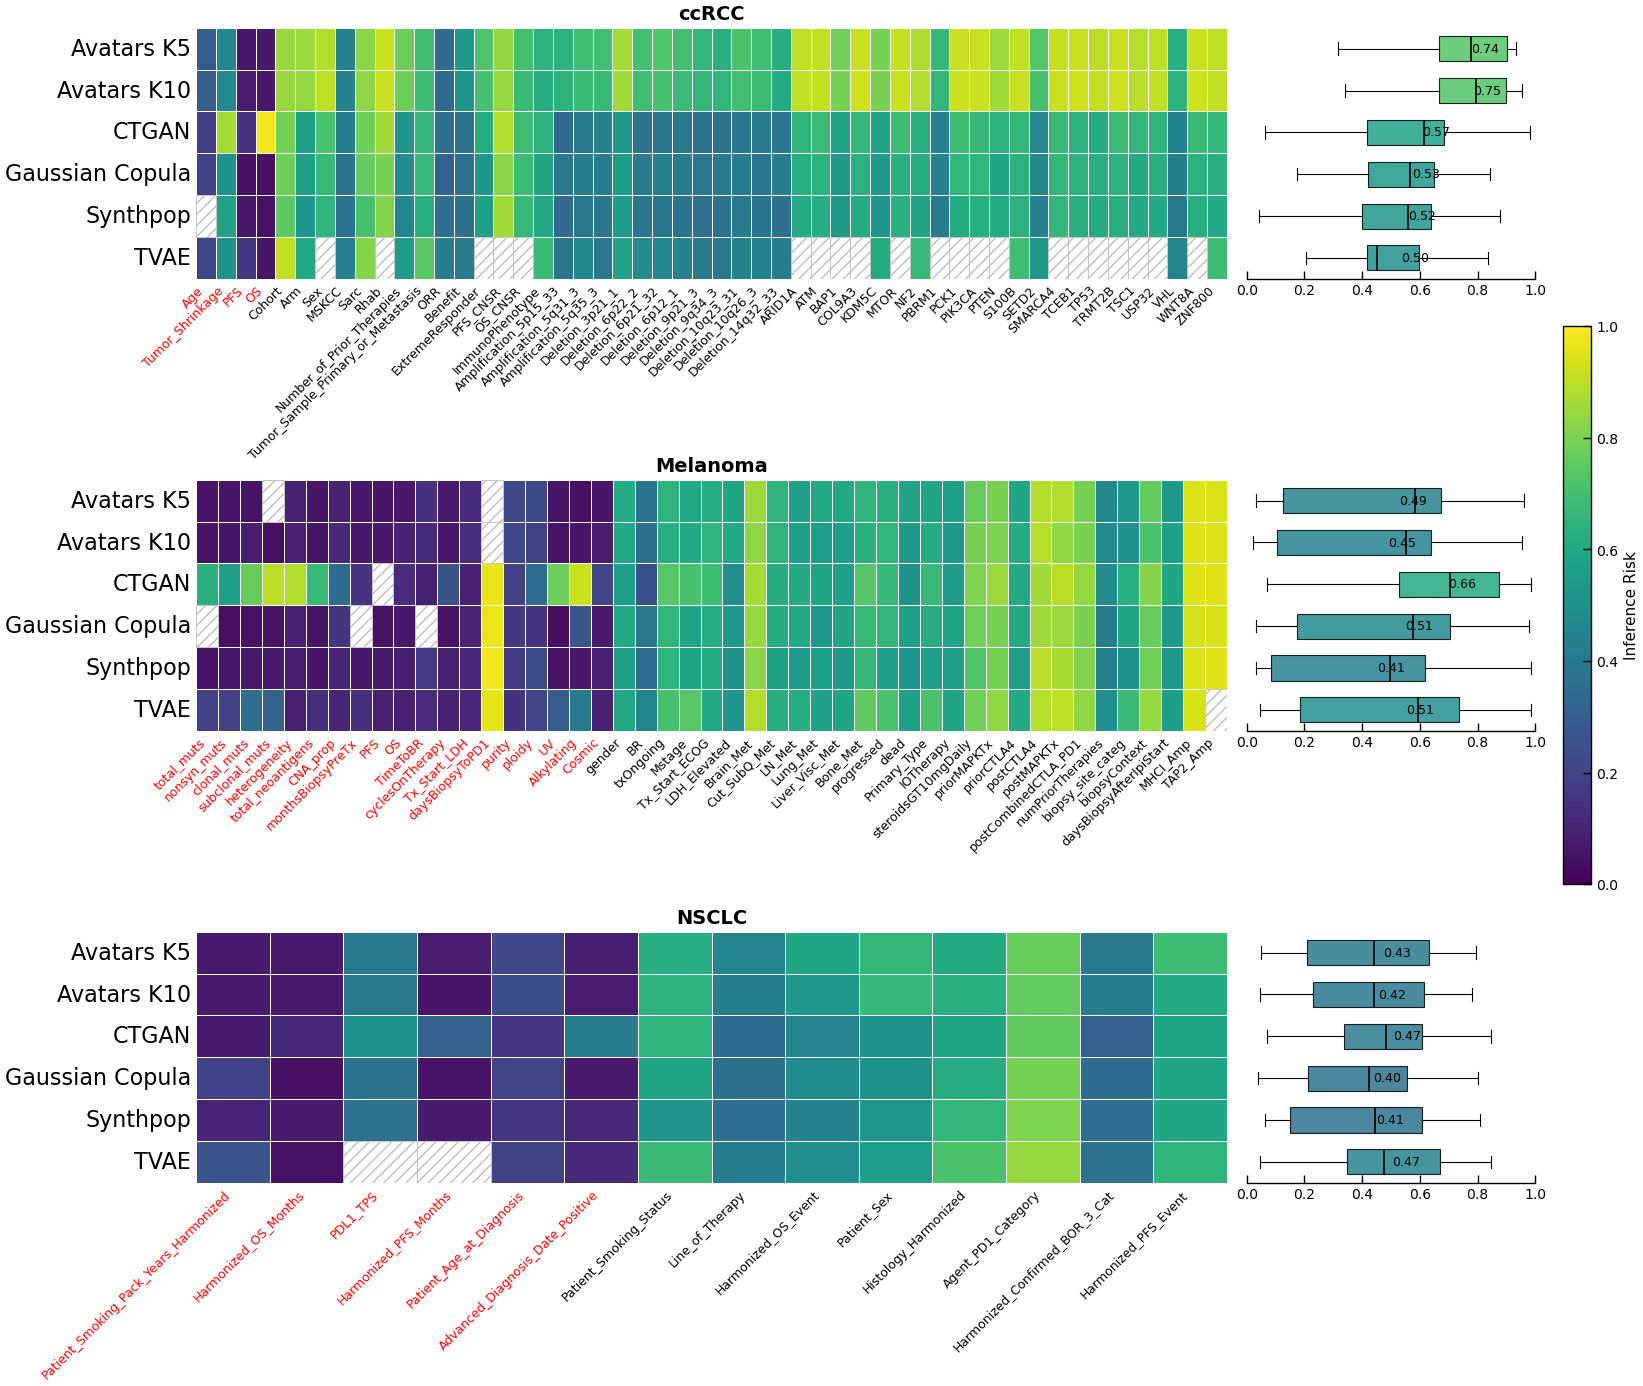

In [8]:
# =========================
# STYLE
# =========================
plt.style.use(["science", "nature", "notebook"])
plt.rcParams.update({
    'text.usetex': False,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False
})

vmin, vmax = 0, 1
cmap = plt.get_cmap("viridis")
norm = colors.Normalize(vmin=vmin, vmax=vmax)

# =========================
# FIGURE LAYOUT
# =========================
fig, axes = plt.subplots(
    3, 2,
    figsize=(18, 15),
    gridspec_kw={
        'width_ratios': [1, 0.28],
        'wspace': 0.03,
        'hspace': 0.8
    }
)

line_params = {'linewidths': 0.4, 'linecolor': 'white'}

# =========================
# PLOTTING
# =========================
for i, cancer in enumerate(cancers):

    ax_heat = axes[i, 0]
    ax_box  = axes[i, 1]

    data_mean = Inference_Agg[cancer]
    data_all  = Inference_Results[cancer]

    # ---- HEATMAP ----
    sns.heatmap(
        data_mean,
        ax=ax_heat,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=True,
        **line_params
    )

    overlay_hatched_missing_cells(ax_heat, data_mean)

    ax_heat.set_title(cancer, fontsize=14, fontweight='bold')
    ax_heat.tick_params(which='major', top=False, bottom=False, left=False, right=False)

    for label in ax_heat.get_xticklabels():
        if label.get_text() in NumericalClinical[cancer]:
            label.set_color("red")
        label.set_rotation(45)
        label.set_fontsize(9)
        label.set_ha("right")

    # ---- BOXPLOT ----
    box_data = collect_boxplot_data(data_all)
    tools = data_mean.index.tolist()

    y_pos = np.arange(len(tools)) + 0.5
    box_values = [box_data[t] for t in tools]

    bp = ax_box.boxplot(
        box_values,
        vert=False,
        positions=y_pos,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(linewidth=0.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8)
    )

    # ---- color by mean ----
    means = data_mean.mean(axis=1).values

    for patch, m in zip(bp['boxes'], means):
        patch.set_facecolor(cmap(norm(m)))
        patch.set_alpha(0.85)

    # ---- annotate mean ----
    for i_t, tool in enumerate(tools):
        vals = box_data[tool]
        y = y_pos[i_t]

        if len(vals) == 0:
            ax_box.text(0.01, y, "NA", va="center", fontsize=9)
        else:
            mean_val = np.mean(vals)
            ax_box.text(
                mean_val + 0.04,
                y,
                f"{mean_val:.2f}",
                va="center",
                fontsize=9
            )

    # ---- clean axis ----
    ax_box.set_ylim(ax_heat.get_ylim())
    ax_box.set_xlim(vmin, vmax)
    ax_box.set_yticks([])
    ax_box.set_ylabel("")

    ax_box.spines['left'].set_visible(False)
    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

    ax_box.tick_params(axis='x', labelsize=10)
    ax_box.tick_params(which='both', left=False)
    ax_box.tick_params(top=False, labeltop=False)
    
    


# =========================
# SHARED COLORBAR
# =========================
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    pad=0.02
)

cbar.set_label("Inference Risk", fontsize=11)
cbar.ax.tick_params(labelsize=10)

# =========================
# SAVE / SHOW
# =========================
fig.savefig(
    "AggreFig/InferenceRisk_MultiSeed_Boxplot.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()